In [11]:
import matplotlib.pyplot as plt

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress INFO, WARNING, and ERROR logs (only show fatal errors)

In [5]:
import pandas as pd
import numpy as np
import joblib
import shap
from tensorflow.keras.models import load_model

X = pd.read_csv("../data/processed/X_features.csv")
y = pd.read_csv("../data/processed/y_target.csv").squeeze()

scaler = joblib.load("../models/scaler.pkl")
model = load_model("../models/neural_network.keras")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Use a small background sample (SHAP needs this as a reference distribution)
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

explainer = shap.KernelExplainer(model.predict, background)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [9]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(50, 16, 5)


In [7]:
X_sample = X_test_scaled[:50]  # explain 50 test students
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", np.array(shap_values).shape)

  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6500/6500 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

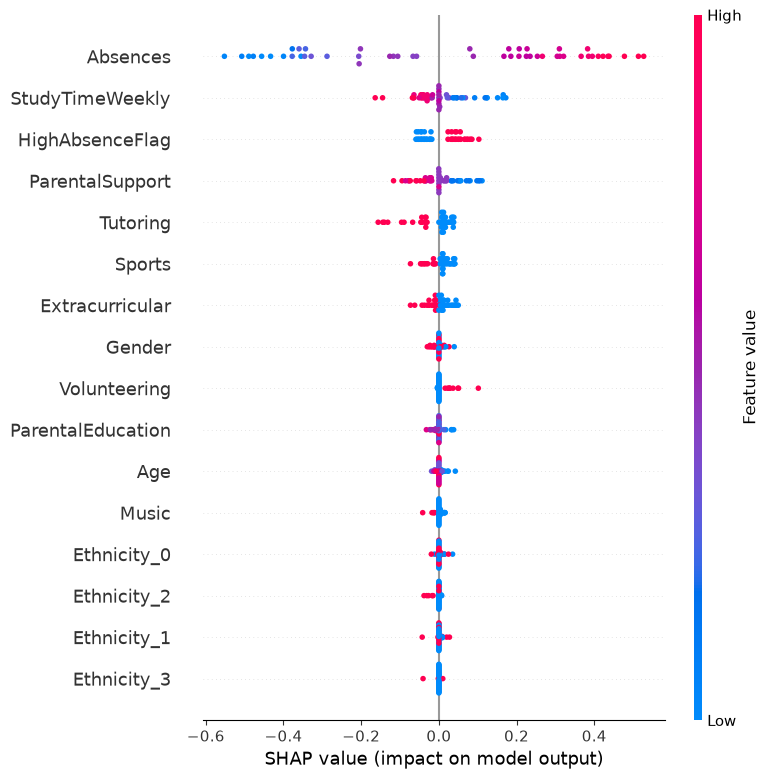

In [13]:
class_idx = 4
shap_values_class4 = shap_values[:, :, class_idx]

shap.summary_plot(
    shap_values_class4,
    X_sample,
    feature_names=X.columns.tolist(),
    show=False
)

plt.savefig('../images/shap_summary_class4.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
plt.savefig('../images/shap_summary_class4.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>